In [28]:
#!/usr/bin/env python
"""
Объединённый скрипт из двух частей:
 1) Валидация гипотез H1 и H2 (код из val.ipynb)
 2) Визуализация результатов (4 панели, hypotheses_overview.png),
    причём для «панели C» используем результаты, уже вычисленные в части 1.
"""

import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Serif'
import warnings
warnings.filterwarnings('ignore')  # Suppress Prophet and PLS warnings

# ---------------------------------------------------------------------
# ЧАСТЬ 1: Валидация гипотез H1 и H2 (взят из val.ipynb)
# ---------------------------------------------------------------------

def convert_to_proportions(values):
    """Convert array of values to proportions that sum to 1."""
    total = np.sum(values)
    if total == 0:
        return np.zeros_like(values)  # avoid division by zero
    return values / total

def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"\n{model_name} Performance:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    return {'mse': mse, 'mae': mae}

def fit_prophet_safely(df, periods=1):
    """Safely fit Prophet: fallback к среднему, если учёт не сходится."""
    try:
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            interval_width=0.95,
            mcmc_samples=0
        )
        model.fit(df)
        future = model.make_future_dataframe(periods=periods, freq='2W')
        forecast = model.predict(future)
        return forecast['yhat'].values[-periods:]
    except:
        return [df['y'].tail(5).mean()] * periods

def fit_pls_safely(X_tr, y_tr, X_te, n_components, return_model=False):
    """
    Fit PLS с «попытками» уменьшить n_components при ошибках.
    В fallback возвращает среднее y_tr.
    """
    try:
        eps = 1e-10
        X_tr_stable = X_tr + eps
        X_te_stable = X_te + eps

        pls = PLSRegression(n_components=n_components, scale=False)
        pls.fit(X_tr_stable, y_tr)
        if return_model:
            return pls.predict(X_te_stable), pls
        return pls.predict(X_te_stable)
    except:
        try:
            n_components_new = max(1, n_components - 1)
            print(f"Retrying PLS with {n_components_new} components...")
            pls = PLSRegression(n_components=n_components_new, scale=False)
            pls.fit(X_tr_stable, y_tr)
            if return_model:
                return pls.predict(X_te_stable), pls
            return pls.predict(X_te_stable)
        except:
            print("PLS fallback to mean prediction...")
            mean_pred = np.tile(np.mean(y_tr, axis=0), (X_te.shape[0], 1))
            if return_model:
                return mean_pred, None
            return mean_pred

print("Loading synthetic data for validation...")
df = pd.read_csv('synthetic_data_confirming.csv', parse_dates=['Time'])

# --- Подготовка матриц ---
vocab    = df['Topic'].unique()
clusters = df['Cluster'].unique()
dates    = df['Time'].unique()
num_dates = len(dates)
test_size = 2  # две точки вперёд (4 недели)

# Word frequency matrix: Time × Topic
word_matrix = pd.pivot_table(
    df, values='Count', index='Time', columns='Topic', aggfunc='sum'
).fillna(0)

# Cluster matrix: Time × Cluster
cluster_matrix = pd.pivot_table(
    df, values='Count', index='Time', columns='Cluster', aggfunc='sum'
).fillna(0)

# Train/test split для сырых значений (нужны для некоторых визуализаций)
X_raw = word_matrix.values                # (num_dates, num_words)
y_raw = cluster_matrix.values             # (num_dates, num_clusters)

# Convert both features and targets to proportions (будем использовать позже в H2)
X_props = np.array([convert_to_proportions(X_raw[i]) for i in range(X_raw.shape[0])])  # word proportions
y_props = np.array([convert_to_proportions(y_raw[i]) for i in range(y_raw.shape[0])])  # cluster proportions

# Split into train/test для raw значений (для H1)
X_train_raw = X_raw[:-test_size]
y_train_raw = y_raw[:-test_size]
X_test_raw = X_raw[-test_size:]
y_test_raw = y_raw[-test_size:]

# Split для proportions (для H2)
X_train_props = X_props[:-test_size]
y_train_props = y_props[:-test_size]
X_test_props = X_props[-test_size:]
y_test_props = y_props[-test_size:]

# Стандартизация признаков для raw значений (для H1)
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)


Loading synthetic data for validation...


In [14]:
X_raw

array([[2.19925251e+02, 2.19750744e+02, 2.20328193e+02, ...,
        3.83055032e+00, 8.95547401e+00, 3.03263170e+00],
       [2.46045238e+02, 2.44298317e+02, 2.37402910e+02, ...,
        1.18026206e+01, 1.06254208e+01, 5.93114410e+00],
       [2.46734496e+02, 2.51465553e+02, 2.52147178e+02, ...,
        8.56134033e+00, 0.00000000e+00, 9.95058959e+00],
       ...,
       [4.99137825e+02, 5.03576791e+02, 4.96550885e+02, ...,
        6.27976224e+00, 1.17261840e+01, 0.00000000e+00],
       [4.81589199e+02, 5.11156770e+02, 5.11546718e+02, ...,
        5.00723285e+00, 5.00124239e+00, 1.95115881e+00],
       [4.81566471e+02, 5.01243481e+02, 5.20773700e+02, ...,
        9.74682136e-02, 4.94419807e+00, 4.11331809e+00]])

In [13]:
X_props

array([[7.24460687e-02, 7.23885838e-02, 7.25788026e-02, ...,
        1.26183014e-03, 2.95004272e-03, 9.98985989e-04],
       [7.36938031e-02, 7.31705773e-02, 7.11053115e-02, ...,
        3.53504097e-03, 3.18245408e-03, 1.77645611e-03],
       [7.23436145e-02, 7.37307807e-02, 7.39306360e-02, ...,
        2.51022177e-03, 0.00000000e+00, 2.91755562e-03],
       ...,
       [7.73811199e-02, 7.80692909e-02, 7.69800676e-02, ...,
        9.73548809e-04, 1.81790520e-03, 0.00000000e+00],
       [7.47100019e-02, 7.92968849e-02, 7.93573783e-02, ...,
        7.76783152e-04, 7.75853838e-04, 3.02687600e-04],
       [7.45991133e-02, 7.76472648e-02, 8.06726768e-02, ...,
        1.50987304e-05, 7.65902144e-04, 6.37191127e-04]])

In [15]:
word_matrix

Topic,Music_core1,Music_core2,Music_core3,Music_core4,Music_noiseSD1,Music_noiseSD2,Music_noiseSD3,Music_noiseSD4,Music_noiseSD5,Music_noiseSD6,...,Tech_noiseSD7,Tech_noiseSD8,Tech_noiseWN1,Tech_noiseWN2,Tech_noiseWN3,Tech_noiseWN4,Tech_noiseWN5,Tech_noiseWN6,Tech_noiseWN7,Tech_noiseWN8
Time,,,,,,,,,,,,,,,,,,,,,
2024-01-07,219.925251,219.750744,220.328193,219.777920,22.191806,21.582285,16.502992,15.592469,9.254181,11.086699,...,9.475893,14.224420,5.739229,0.000000,10.816743,2.156964,11.605758,3.830550,8.955474,3.032632
2024-01-21,246.045238,244.298317,237.402910,227.952463,30.912433,29.624058,22.235561,26.836168,14.066028,5.573662,...,0.000000,29.202366,8.308912,10.370230,7.563166,4.913286,16.750085,11.802621,10.625421,5.931144
2024-02-04,246.734496,251.465553,252.147178,233.820794,13.750701,32.618106,14.521067,11.138891,6.601020,24.535509,...,10.424239,19.285191,5.261615,2.101634,1.122636,8.277705,0.000000,8.561340,0.000000,9.950590
2024-02-18,229.922917,242.075607,262.067718,240.720478,37.310024,42.534413,24.156926,21.930677,0.668612,10.223897,...,13.053693,15.470138,15.170306,5.880758,15.651865,5.038534,7.980195,0.000000,0.423651,0.000000
2024-03-03,230.191607,232.047694,266.673372,248.976006,20.909769,57.796655,21.748700,18.342079,4.928340,13.615837,...,16.233381,23.300853,1.264104,14.673324,0.000000,2.381685,2.208137,8.935405,0.385146,1.051301
2024-03-17,255.405776,238.451193,266.259484,255.799178,45.169216,85.759459,18.115908,21.611554,12.312142,9.718530,...,0.000000,43.414870,6.167645,10.381036,10.514925,4.342341,4.364310,6.168417,0.000000,3.177644
2024-03-31,282.327950,262.867058,263.133153,262.791507,73.151444,361.814698,24.527458,31.670811,7.666057,26.167894,...,5.825667,44.064611,0.545176,3.388816,11.003494,4.469822,20.866060,4.887747,9.976849,0.000000
2024-04-14,282.511557,287.909074,260.458685,270.683343,94.083948,195.407948,27.721456,28.761300,0.000000,27.683324,...,0.000000,56.710276,0.000000,0.000000,0.976279,2.779934,0.000000,2.668889,3.837043,0.084453
2024-04-28,265.877209,294.699619,260.762096,277.697520,362.238354,126.312420,35.474170,33.229776,10.502940,27.785575,...,0.000000,90.960109,1.329385,0.000000,13.354792,3.447224,6.522438,11.744676,3.412911,2.142675


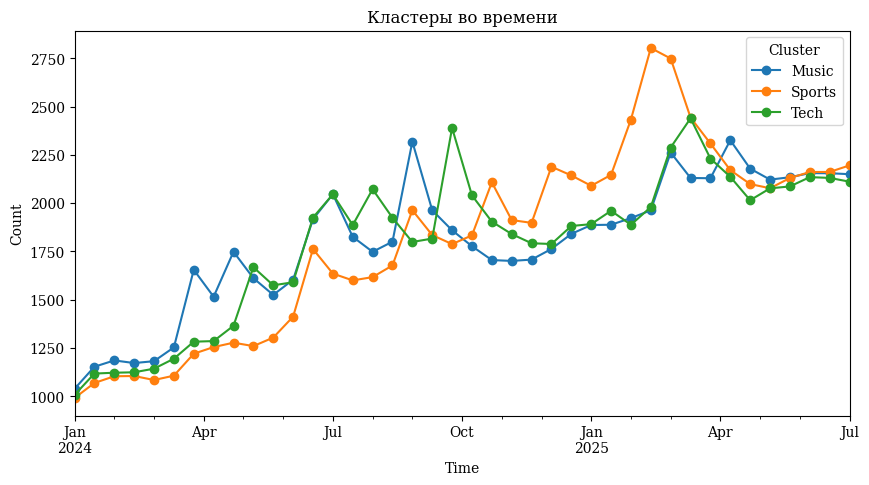

In [10]:
cluster_matrix.plot(figsize=(10, 5), marker='o')
plt.title('Кластеры во времени')
plt.ylabel('Count')
plt.xlabel('Time')
plt.legend(title='Cluster')
plt.show()

In [9]:
cluster_matrix

Cluster,Music,Sports,Tech
Time,,,
2024-01-07,1038.257486,990.760937,1006.691521
2024-01-21,1152.727232,1068.703916,1117.319567
2024-02-04,1185.456965,1103.387537,1121.746716
2024-02-18,1171.805009,1104.753320,1123.994965
2024-03-03,1181.455021,1083.998076,1142.708973
2024-03-17,1252.903534,1106.497382,1194.267861
2024-03-31,1654.542833,1220.131628,1282.372472
2024-04-14,1515.237887,1254.526993,1285.572016
2024-04-28,1747.934625,1277.247551,1364.818580


In [29]:
# ================
# H1: Feature Selection через PLS (используем raw значения)
# ================
print("\n=== Hypothesis 1: Feature Selection ===")
results = []

n_components = min(3, X_train_scaled.shape[1] - 1)
# 1) Full model (все признаки)
y_pred_full, pls_model = fit_pls_safely(
    X_train_scaled, y_train_raw, X_test_scaled, n_components, return_model=True
)
full_metrics = evaluate_model(y_test_raw, y_pred_full, "Full Model (All Features, Raw)")
results.append({"method": "Full Model (Raw)", **full_metrics})

# 2) Рассчитываем importance признаков по |coef|
coef_abs = np.abs(pls_model.coef_)
if coef_abs.shape[0] == X_train_scaled.shape[1]:
    importance = coef_abs.sum(axis=1)   # (n_features,)
else:
    importance = coef_abs.sum(axis=0)   # (n_features,)

top_k = int(len(vocab) * 0.2)           # 20% от всех слов
selected_idx   = np.argsort(importance)[::-1][:top_k]
selected_vocab = [vocab[i] for i in selected_idx]

# 3) PLS только на отобранных признаках (raw значения)
X_train_sel_scaled = X_train_scaled[:, selected_idx]
X_test_sel_scaled  = X_test_scaled[:,  selected_idx]

# Для H2 нам понадобятся пропорции для отобранных признаков
X_train_sel_props = X_train_props[:, selected_idx]

pls_selected = PLSRegression(
    n_components=min(3, X_train_sel_scaled.shape[1] - 1),
    scale=False
)
pls_selected.fit(X_train_sel_scaled, y_train_raw)
y_pred_selected = pls_selected.predict(X_test_sel_scaled)
selected_metrics = evaluate_model(y_test_raw, y_pred_selected, "Selected Features Model (Raw)")
results.append({"method": "Selected Features (Raw)", **selected_metrics})



=== Hypothesis 1: Feature Selection ===

Full Model (All Features, Raw) Performance:
MSE: 4571.9552
MAE: 59.3100

Selected Features Model (Raw) Performance:
MSE: 122720.7282
MAE: 318.4574


In [24]:
X_train_sel_props.shape

(38, 12)

In [32]:

# ================
# H2: Word-level Prediction → Cluster (используем пропорции)
# ================
print("\n=== Hypothesis 2: Word-level vs Direct Prediction (Proportions) ===")

# 1) Direct Prophet на пропорциях кластеров
cluster_predictions = np.zeros((test_size, len(clusters)))
for i, cluster in enumerate(clusters):
    df_cluster = pd.DataFrame({
        'ds': dates[:-test_size],
        'y': y_train_props[:, i]  # используем пропорции
    })
    cluster_predictions[:, i] = fit_prophet_safely(df_cluster, periods=test_size)

# 2) Word-level Prophet по selected_vocab (тоже пропорции)
word_predictions = np.zeros((test_size, len(selected_vocab)))
for i, word in enumerate(selected_vocab):
    df_word = pd.DataFrame({
        'ds': dates[:-test_size],
        'y': X_train_sel_props[:, i]  # используем пропорции отобранных слов
    })
    word_predictions[:, i] = fit_prophet_safely(df_word, periods=test_size)

# 3) Агрегируем прогнозы слов → кластеры и проверяем суммы
print("\nDebug sums before aggregation:")
print(f"Sum of word predictions t+1: {word_predictions[0].sum():.3f}")
print(f"Sum of word predictions t+2: {word_predictions[1].sum()}")

cluster_from_words = np.zeros((test_size, len(clusters)))

# Сначала собираем слова по кластерам
cluster_word_mapping = {}
for ci, cluster in enumerate(clusters):
    idxs = [
        idx_sel for idx_sel, w in enumerate(selected_vocab)
        if df[df['Topic'] == w]['Cluster'].iloc[0] == cluster
    ]
    cluster_word_mapping[cluster] = idxs

# Выводим информацию по каждому кластеру до нормализации
print("\nPre-normalization analysis:")
for cluster, idxs in cluster_word_mapping.items():
    ci = list(clusters).index(cluster)
    cluster_from_words[:, ci] = word_predictions[:, idxs].sum(axis=1) if len(idxs) > 0 else 0
    
    print(f"\nCluster: {cluster}")
    print(f"Number of selected words: {len(idxs)}")
    print(f"True proportions: t+1={y_test_props[0, ci]:.3f}, t+2={y_test_props[1, ci]:.3f}")
    print(f"Direct Prophet:  t+1={cluster_predictions[0, ci]:.3f}, t+2={cluster_predictions[1, ci]:.3f}")
    print(f"Word-based sum:  t+1={cluster_from_words[0, ci]:.3f}, t+2={cluster_from_words[1, ci]:.3f}")
    
    if idxs:
        print("\nContributing words:")
        for idx_sel in idxs:
            w = selected_vocab[idx_sel]
            print(f"  {w:<25s}: t+1={word_predictions[0, idx_sel]:.3f}, t+2={word_predictions[1, idx_sel]:.3f}")

print("\nSums across clusters before normalization:")
print(f"t+1: {cluster_from_words[0].sum():.3f}")
print(f"t+2: {cluster_from_words[1].sum():.3f}")

# Нормализуем предсказания, чтобы сумма по кластерам = 1
print("\nAfter normalization:")
for t in range(test_size):
    cluster_from_words[t] = convert_to_proportions(cluster_from_words[t])
print("\nFinal normalized proportions:")
for t in range(test_size):
    print(f"\nTime point t+{t+1}, sum={cluster_from_words[t].sum():.3f}:")
    for ci, cluster in enumerate(clusters):
        print(f"  {cluster:<6s}: {cluster_from_words[t, ci]:.3f}")

# Evaluate metrics for H2 (все значения уже в пропорциях) с большей точностью и детальным анализом
def evaluate_model_detailed(y_true, y_pred, model_name):
    # Проверяем входные данные
    print(f"\n{model_name} Input Validation:")
    print(f"Shape y_true: {y_true.shape}, y_pred: {y_pred.shape}")
    print(f"y_true sums: t+1={y_true[0].sum():.3f}, t+2={y_true[1].sum():.3f}")
    print(f"y_pred sums: t+1={y_pred[0].sum():.3f}, t+2={y_pred[1].sum():.3f}")
    
    # Нормализуем предсказания в пропорции
    # y_pred_norm = np.array([convert_to_proportions(y_pred[i]) for i in range(y_pred.shape[0])])
    y_pred_norm = y_pred
    
    # Масштабируем относительно исходного диапазона значений
    def scale_to_01(x):
        # Используем теоретический диапазон для пропорций [0, 1]
        # и добавляем небольшой отступ для численной стабильности
        eps = 1e-6
        global_min = 0 - eps
        global_max = 1 + eps
        return (x - global_min) / (global_max - global_min)
    
    # y_true_scaled = scale_to_01(y_true)
    # y_pred_scaled = scale_to_01(y_pred_norm)
    y_true_scaled = y_true
    y_pred_scaled = y_pred_norm
    
    print("\nAfter scaling to [0,1]:")
    print(f"Global range: [{min(y_true.min(), y_pred_norm.min()):.3f}, {max(y_true.max(), y_pred_norm.max()):.3f}]")
    print(f"y_true range: [{y_true_scaled.min():.3f}, {y_true_scaled.max():.3f}]")
    print(f"y_pred range: [{y_pred_scaled.min():.3f}, {y_pred_scaled.max():.3f}]")
    
    # Проверяем сохранение относительных разниц
    print("\nValidating relative differences preservation:")
    orig_diffs = np.abs(y_true - y_pred_norm)
    scaled_diffs = np.abs(y_true_scaled - y_pred_scaled)
    print(f"Original max diff: {orig_diffs.max():.6f}")
    print(f"Scaled max diff: {scaled_diffs.max():.6f}")
    correlation = np.corrcoef(orig_diffs.flatten(), scaled_diffs.flatten())[0,1]
    print(f"Correlation between original and scaled differences: {correlation:.6f}")
    
    # Считаем метрики на масштабированных данных
    mse = mean_squared_error(y_true_scaled, y_pred_scaled)
    mae = mean_absolute_error(y_true_scaled, y_pred_scaled)
    
    print(f"\n{model_name} Performance:")
    print(f"MSE: {mse:.6f}")
    print(f"MAE: {mae:.6f}")
    
    # Детальный анализ ошибок
    print("\nDetailed error analysis by cluster:")
    cluster_names = ['Sports', 'Music', 'Tech']
    for t in range(y_true.shape[0]):
        print(f"\nTime point t+{t+1}:")
        for c in range(y_true.shape[1]):
            error = y_pred_norm[t,c] - y_true[t,c]
            rel_error = abs(error / y_true[t,c]) * 100 if y_true[t,c] != 0 else float('inf')
            print(f"  {cluster_names[c]:<6s}: true={y_true[t,c]:.4f}, pred={y_pred_norm[t,c]:.4f}, "
                  f"error={error:.4f} ({rel_error:.1f}%)")
    
    # Возвращаем метрики для дальнейшего анализа
    return {'mse': mse, 'mae': mae}

# Вычисляем и анализируем метрики
direct_metrics = evaluate_model_detailed(y_test_props, cluster_predictions, "Direct Cluster Prediction (Proportions)")
word_based_metrics = evaluate_model_detailed(y_test_props, cluster_from_words, "Word-based Prediction (Proportions)")

# Считаем относительное улучшение
rel_improvement_mse = ((direct_metrics['mse'] - word_based_metrics['mse']) / direct_metrics['mse']) * 100
rel_improvement_mae = ((direct_metrics['mae'] - word_based_metrics['mae']) / direct_metrics['mae']) * 100

print("\nRelative Improvement Analysis:")
print(f"MSE improvement: {rel_improvement_mse:.1f}%")
print(f"MAE improvement: {rel_improvement_mae:.1f}%")

results.append({"method": "Direct Cluster (Props)", **direct_metrics})
results.append({"method": "Word-based (Props)", **word_based_metrics})

# Добавляем наивный метод (использование последнего известного значения)
naive_predictions = np.zeros_like(cluster_predictions)
for i in range(len(clusters)):
    naive_predictions[:, i] = y_train_props[-1, i]

# Оцениваем все методы
print("\nEvaluating all methods:")
naive_metrics = evaluate_model_detailed(y_test_props, naive_predictions, "Naive Last Value Method")
direct_metrics = evaluate_model_detailed(y_test_props, cluster_predictions, "Direct Cluster Prediction")
word_based_metrics = evaluate_model_detailed(y_test_props, cluster_from_words, "Word-based Prediction")

# Считаем улучшение относительно наивного метода
print("\nImprovement over naive method:")
direct_vs_naive_mse = ((naive_metrics['mse'] - direct_metrics['mse']) / naive_metrics['mse']) * 100
word_vs_naive_mse = ((naive_metrics['mse'] - word_based_metrics['mse']) / naive_metrics['mse']) * 100
print(f"Direct method MSE improvement vs naive: {direct_vs_naive_mse:.1f}%")
print(f"Word-based MSE improvement vs naive: {word_vs_naive_mse:.1f}%")

# Считаем относительное улучшение word-based vs direct
rel_improvement_mse = ((direct_metrics['mse'] - word_based_metrics['mse']) / direct_metrics['mse']) * 100
rel_improvement_mae = ((direct_metrics['mae'] - word_based_metrics['mae']) / direct_metrics['mae']) * 100

print("\nWord-based vs Direct improvement:")
print(f"MSE improvement: {rel_improvement_mse:.1f}%")
print(f"MAE improvement: {rel_improvement_mae:.1f}%")

# Сохраняем результаты части 1
results_df = pd.DataFrame(results)
results_df.to_csv('hypothesis_test_results.csv', index=False)
print("\nResults saved to hypothesis_test_results.csv")

plt.figure(figsize=(12, 6))
plt.bar(results_df['method'], results_df['mse'])
plt.title('MSE Comparison Across Methods')
plt.ylabel('Mean Squared Error')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('hypothesis_comparison.png')
plt.close()
print("Bar chart saved as hypothesis_comparison.png")


00:35:23 - cmdstanpy - INFO - Chain [1] start processing



=== Hypothesis 2: Word-level vs Direct Prediction (Proportions) ===


00:35:23 - cmdstanpy - INFO - Chain [1] done processing
00:35:23 - cmdstanpy - INFO - Chain [1] start processing
00:35:24 - cmdstanpy - INFO - Chain [1] done processing
00:35:24 - cmdstanpy - INFO - Chain [1] start processing
00:35:24 - cmdstanpy - INFO - Chain [1] done processing
00:35:24 - cmdstanpy - INFO - Chain [1] start processing
00:35:24 - cmdstanpy - INFO - Chain [1] done processing
00:35:24 - cmdstanpy - INFO - Chain [1] start processing
00:35:25 - cmdstanpy - INFO - Chain [1] done processing
00:35:25 - cmdstanpy - INFO - Chain [1] start processing
00:35:25 - cmdstanpy - INFO - Chain [1] done processing
00:35:25 - cmdstanpy - INFO - Chain [1] start processing
00:35:25 - cmdstanpy - INFO - Chain [1] done processing
00:35:26 - cmdstanpy - INFO - Chain [1] start processing
00:35:26 - cmdstanpy - INFO - Chain [1] done processing
00:35:26 - cmdstanpy - INFO - Chain [1] start processing
00:35:26 - cmdstanpy - INFO - Chain [1] done processing
00:35:26 - cmdstanpy - INFO - Chain [1] 


Debug sums before aggregation:
Sum of word predictions t+1: 0.745
Sum of word predictions t+2: 0.727949350459312

Pre-normalization analysis:

Cluster: Sports
Number of selected words: 4
True proportions: t+1=0.334, t+2=0.333
Direct Prophet:  t+1=0.312, t+2=0.315
Word-based sum:  t+1=0.248, t+2=0.242

Contributing words:
  Sports_core2             : t+1=0.068, t+2=0.071
  Sports_core4             : t+1=0.058, t+2=0.056
  Sports_core3             : t+1=0.057, t+2=0.057
  Sports_core1             : t+1=0.065, t+2=0.059

Cluster: Music
Number of selected words: 4
True proportions: t+1=0.335, t+2=0.340
Direct Prophet:  t+1=0.351, t+2=0.341
Word-based sum:  t+1=0.251, t+2=0.246

Contributing words:
  Music_core2              : t+1=0.068, t+2=0.071
  Music_core4              : t+1=0.061, t+2=0.059
  Music_core3              : t+1=0.057, t+2=0.057
  Music_core1              : t+1=0.065, t+2=0.060

Cluster: Tech
Number of selected words: 4
True proportions: t+1=0.330, t+2=0.327
Direct Prophet

✓ saved hypotheses_overview_proportions.png


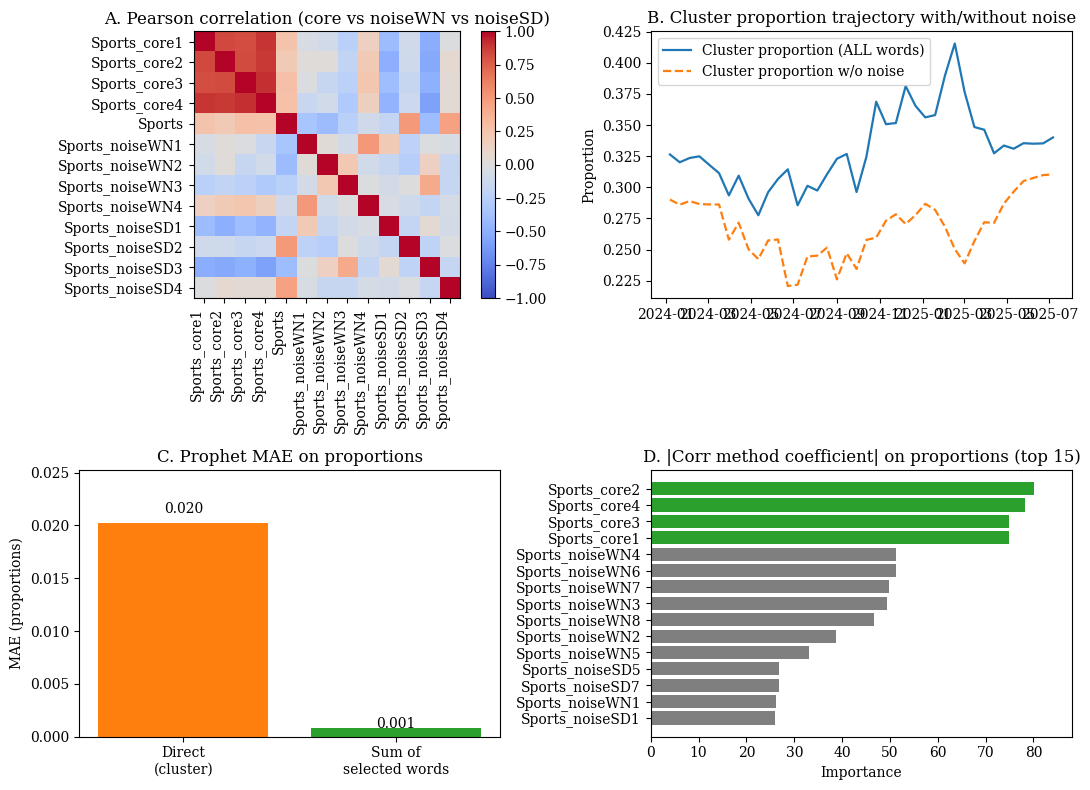

In [33]:

# ---------------------------------------------------------------------
# ЧАСТЬ 2: Визуализация «hypotheses overview» (4 панели)
#           (используем данные, посчитанные выше, где это возможно)
# ---------------------------------------------------------------------

OUT_PNG = "hypotheses_overview_proportions.png"  # новое имя для версии с долями
TEST_H  = test_size   # уже равен 2
TOP_SHOW= 15
CLUSTER = "Sports"    # фиксируем один кластер для панелей

# 1) Фильтрация по CLUSTER
df_vis    = df[df["Cluster"] == CLUSTER].copy()
core      = [t for t in df_vis["Topic"].unique() if "_core" in t]
noise     = [t for t in df_vis["Topic"].unique() if "_noise" in t]
topics    = core + noise

# Матрица Time × Topic для выбранного кластера (уже в долях!)
mat_raw = df_vis.pivot_table(
    index="Time", columns="Topic", values="Count", aggfunc="sum"
).fillna(0)

# Конвертируем в доли относительно всех кластеров
total_counts = df.pivot_table(
    index="Time", columns="Cluster", values="Count", aggfunc="sum"
).fillna(0).sum(axis=1)
mat = mat_raw.div(total_counts, axis=0)  # делим каждую строку на общую сумму

cluster_series    = mat.sum(axis=1)    # суммарный ряд по всем словам кластера (в долях)
cluster_core_only = mat[core].sum(axis=1)  # суммарный ряд только core-слов (в долях)

# Индексы train/test внутри mat
train_idx = slice(None, -TEST_H)
test_idx  = slice(-TEST_H, None)

# Predictions are already proportions from H2
cluster_predictions_props = cluster_predictions  # уже пропорции
cluster_from_words_props = cluster_from_words   # уже пропорции

# ---------------------------------------------------
# A: Heat-map корреляций (core vs noise vs cluster)
# ---------------------------------------------------
fig = plt.figure(figsize=(11, 8))
gs  = fig.add_gridspec(2, 2)


ax = fig.add_subplot(gs[0, 0])

# Список всех слов (только в рамках данного кластера)
all_topics = mat.columns.tolist()

# Делим шумихи на два типа по имени: white-noise и spike+decay
white_noise_topics = [t for t in all_topics if "_noiseWN" in t]
spike_decay_topics = [t for t in all_topics if "_noiseSD" in t]

# Возьмём по len(core) случайных (или просто первых) представителей каждого типа
n_show = len(core)
sel_white = white_noise_topics[:n_show]
sel_spike = spike_decay_topics[:n_show]

# Итоговый список колонок: core-слова, кластер, затем white-noise и spike+decay
sel_cols = core + [CLUSTER] + sel_white + sel_spike

corr = mat.assign(**{CLUSTER: cluster_series}).corr()
c = ax.imshow(corr.loc[sel_cols, sel_cols],
              cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(sel_cols)))
ax.set_xticklabels(sel_cols, rotation=90, ha="right")
ax.set_yticks(range(len(sel_cols)))
ax.set_yticklabels(sel_cols)
ax.set_title("A. Pearson correlation (core vs noiseWN vs noiseSD)")
fig.colorbar(c, ax=ax, fraction=0.045)


# ---------------------------------------------------
# B: Суммарная траектория кластера (all vs core-only) в долях
# ---------------------------------------------------
ax = fig.add_subplot(gs[0, 1])
ax.plot(cluster_series.index, cluster_series.values,
        label="Cluster proportion (ALL words)", lw=1.6)
ax.plot(cluster_core_only.index, cluster_core_only.values,
        label="Cluster proportion w/o noise", ls="--", lw=1.6)
ax.set_title("B. Cluster proportion trajectory with/without noise")
ax.set_ylabel("Proportion")
ax.legend()

# ---------------------------------------------------
# C: MAE Direct Prophet vs Prophet(sum of selected words) для долей
# ---------------------------------------------------
cluster_idx = list(clusters).index(CLUSTER)

# Используем прогнозы в долях
direct_pred_vis = cluster_predictions_props[:, cluster_idx]
sum_word_pred_vis = cluster_from_words_props[:, cluster_idx]

# Используем true значения в долях
cluster_true_props = y_test_props[:, cluster_idx]  # уже в долях

mae_direct_vis = mean_absolute_error(cluster_true_props, direct_pred_vis)
mae_word_vis   = mean_absolute_error(cluster_true_props, sum_word_pred_vis)

ax = fig.add_subplot(gs[1, 0])
ax.bar(
    ["Direct\n(cluster)", "Sum of\nselected words"],
    [mae_direct_vis, mae_word_vis],
    color=["tab:orange", "tab:green"]
)
ax.set_title("C. Prophet MAE on proportions")
ax.set_ylabel("MAE (proportions)")
ax.set_ylim(0, max(mae_direct_vis, mae_word_vis) * 1.25)
for i, v in enumerate([mae_direct_vis, mae_word_vis]):
    ax.text(i, v * 1.05, f"{v:.3f}", ha="center")

# ---------------------------------------------------
# D: PLS-коэффициенты (|coef|) для топ-15 слов из H1
# ---------------------------------------------------
# Используем importance из H1 для визуализации
cluster_words = df_vis['Topic'].unique()
importance_vis = {word: importance[list(vocab).index(word)] for word in cluster_words if word in vocab}
coefs_vis = pd.Series(importance_vis)
top_imp_vis = coefs_vis.nlargest(TOP_SHOW)

ax = fig.add_subplot(gs[1, 1])
colors = ["tab:green" if t in core else "tab:gray" for t in top_imp_vis.index[::-1]]
ax.barh(top_imp_vis.index[::-1], top_imp_vis.values[::-1], color=colors)
ax.set_title("D. |Corr method coefficient| on proportions (top 15)")
ax.set_xlabel("Importance")
ax.set_xlim(0, top_imp_vis.values.max() * 1.1)

# ---------------------------------------------------
# Сохраняем окончательный рисунок
# ---------------------------------------------------
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150)
print("✓ saved", OUT_PNG)
